# Receive DSP chain: 176.4 kHz vs 192 kHz

Compares the per-stage sweep files produced by the `ReceiveChain176k` test suite
(`176k_*.txt`, generated at Fs = 176.4 kHz / audio rate 22.05 kHz) against the
standard sweeps produced by the existing tests (generated at the default
Fs = 192 kHz / audio rate 24 kHz).

Run the tests first so the `build/` files exist:

```
cd code/test/build && cmake ../ && make all_SigProc_tests && ./all_SigProc_tests
```

**Expectation** (see `docs/RX_DSP_Chain_Parameters.md`):

* **Hard-coded** coefficient tables (CW audio filters, EQ bands) were designed
  for a 24 kHz audio rate. Run at 22.05 kHz their corner/center frequencies
  scale by `176400/192000 = 0.91875`.
* **Fs-derived** stages (e.g. the AM audio lowpass) recompute from the sample
  rate, so their corners stay fixed in Hz.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

RATE_RATIO = 176400 / 192000   # 0.91875

def load_sweep(path):
    """Return (freq_Hz, gain_linear) from a WriteIQFile sweep: idx,freq,gain."""
    d = np.genfromtxt(path, delimiter=',')
    return d[:, 1], d[:, 2]

def minus6dB_cutoff(f, g):
    """First frequency where |gain| falls to half the passband (first-sample) value."""
    target = 0.5 * g[0]
    below = np.where(g <= target)[0]
    if len(below) == 0:
        return np.nan
    i = below[0]
    if i == 0:
        return f[0]
    # linear interpolation between i-1 and i
    return f[i-1] + (target - g[i-1]) * (f[i] - f[i-1]) / (g[i] - g[i-1])

def peak_freq(f, g):
    return f[int(np.argmax(g))]

## CW audio filters (hard-coded @ 24 kHz)

The five selectable CW bandwidths. Solid = 192 kHz, dashed = 176.4 kHz. Every skirt shifts down ~8%.

  filter   192k -6dB   176k -6dB    ratio  (expected 0.9187)
 0.8 kHz       852.6       784.1   0.9196
 1.0 kHz      1093.9      1005.8   0.9195
 1.3 kHz      1338.2      1230.0   0.9192
 1.8 kHz      1823.5      1675.2   0.9187
 2.0 kHz      2065.4      1898.3   0.9191


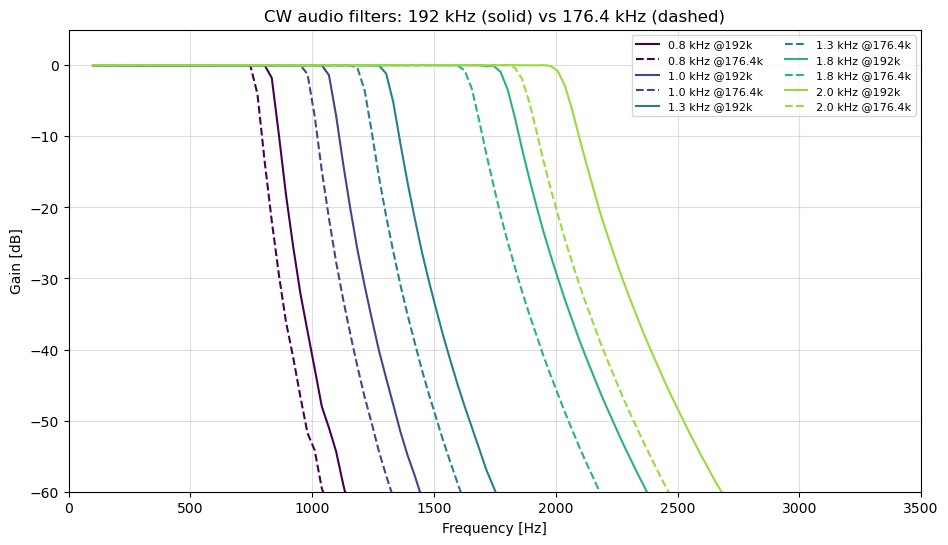

In [2]:
cw_labels = ['0.8 kHz', '1.0 kHz', '1.3 kHz', '1.8 kHz', '2.0 kHz']
colors = plt.cm.viridis(np.linspace(0, 0.85, 5))

plt.figure(figsize=(11, 6))
print(f"{'filter':>8}  {'192k -6dB':>10}  {'176k -6dB':>10}  {'ratio':>7}  (expected {RATE_RATIO:.4f})")
for bf in range(5):
    f0, g0 = load_sweep('build/CWFilter_band_%d.txt' % bf)
    f1, g1 = load_sweep('build/176k_CWFilter_band_%d.txt' % bf)
    plt.plot(f0, 20*np.log10(g0), '-',  color=colors[bf], label='%s @192k' % cw_labels[bf])
    plt.plot(f1, 20*np.log10(g1), '--', color=colors[bf], label='%s @176.4k' % cw_labels[bf])
    c0, c1 = minus6dB_cutoff(f0, g0), minus6dB_cutoff(f1, g1)
    print(f"{cw_labels[bf]:>8}  {c0:10.1f}  {c1:10.1f}  {c1/c0:7.4f}")

plt.ylim(-60, 5)
plt.xlim(0, 3500)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=8, ncol=2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('CW audio filters: 192 kHz (solid) vs 176.4 kHz (dashed)')
plt.show()

## Receive EQ bands (hard-coded @ 24 kHz)

All 14 graphic-EQ cells. Each band center shifts down by the same ~8%.

band   192k peak   176k peak    ratio
   0       198.5       178.8   0.9008
   1       257.6       237.9   0.9235
   2       316.7       297.0   0.9378
   3       395.5       375.8   0.9502
   4       494.0       454.6   0.9202
   5       631.9       572.8   0.9065
   6       789.5       730.4   0.9251
   7      1006.2       927.4   0.9217
   8      1242.6      1163.8   0.9366
   9      1597.3      1459.4   0.9137
  10      1991.3      1833.7   0.9209
  11      2503.5      2306.5   0.9213
  12      3153.6      2897.5   0.9188
  13      4000.7      3646.1   0.9114


/tmp/ipykernel_1024744/2527797174.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(f0, 20*np.log10(g0), '-',  color=colors[bf])


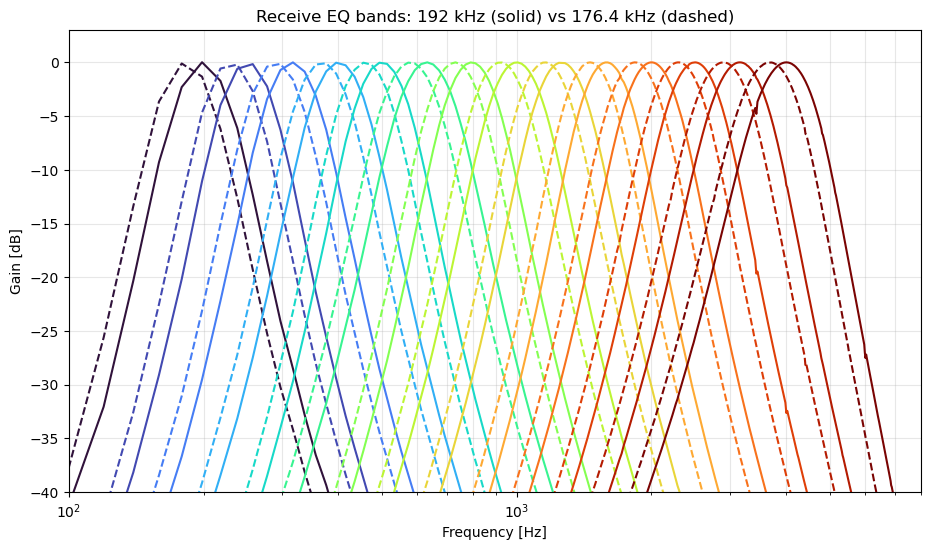

In [3]:
plt.figure(figsize=(11, 6))
colors = plt.cm.turbo(np.linspace(0, 1, 14))
print(f"{'band':>4}  {'192k peak':>10}  {'176k peak':>10}  {'ratio':>7}")
for bf in range(14):
    f0, g0 = load_sweep('build/ReceiveEQ_band_%d.txt' % bf)
    f1, g1 = load_sweep('build/176k_ReceiveEQ_band_%d.txt' % bf)
    plt.semilogx(f0, 20*np.log10(g0), '-',  color=colors[bf])
    plt.semilogx(f1, 20*np.log10(g1), '--', color=colors[bf])
    p0, p1 = peak_freq(f0, g0), peak_freq(f1, g1)
    print(f"{bf:>4}  {p0:10.1f}  {p1:10.1f}  {p1/p0:7.4f}")

plt.ylim(-40, 3)
plt.xlim(100, 8000)
plt.grid(True, which='both', alpha=0.3)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('Receive EQ bands: 192 kHz (solid) vs 176.4 kHz (dashed)')
plt.show()

### EQ top band zoom

Zoom on the highest band to see the center-frequency shift clearly.

/tmp/ipykernel_1024744/1314273394.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (peak %.0f Hz)' % p0)


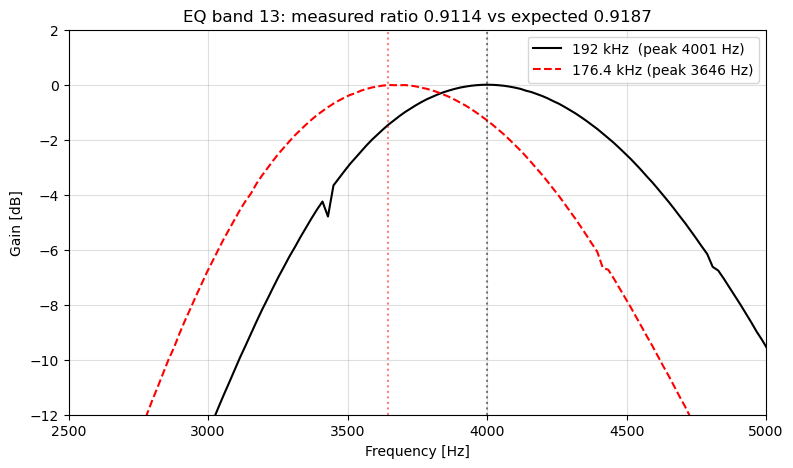

In [4]:
bf = 13
f0, g0 = load_sweep('build/ReceiveEQ_band_%d.txt' % bf)
f1, g1 = load_sweep('build/176k_ReceiveEQ_band_%d.txt' % bf)
p0, p1 = peak_freq(f0, g0), peak_freq(f1, g1)

plt.figure(figsize=(9, 5))
plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (peak %.0f Hz)' % p0)
plt.plot(f1, 20*np.log10(g1), 'r--', label='176.4 kHz (peak %.0f Hz)' % p1)
plt.axvline(p0, color='k', ls=':', alpha=0.5)
plt.axvline(p1, color='r', ls=':', alpha=0.5)
plt.xlim(2500, 5000)
plt.ylim(-12, 2)
plt.grid(True, alpha=0.4)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('EQ band 13: measured ratio %.4f vs expected %.4f' % (p1/p0, RATE_RATIO))
plt.show()

## AM audio lowpass IIR (Fs-derived control)

This stage recomputes its coefficients from the sample rate, so the two curves should lie almost on top of each other — the corner stays fixed in Hz.

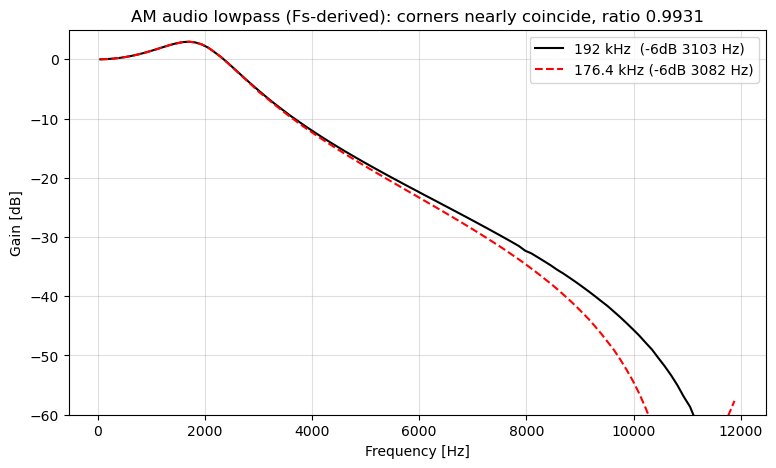

In [5]:
f0, g0 = load_sweep('build/AudioIIRPassband.txt')
f1, g1 = load_sweep('build/176k_AudioIIRPassband.txt')
c0, c1 = minus6dB_cutoff(f0, g0), minus6dB_cutoff(f1, g1)

plt.figure(figsize=(9, 5))
plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (-6dB %.0f Hz)' % c0)
plt.plot(f1, 20*np.log10(g1), 'r--', label='176.4 kHz (-6dB %.0f Hz)' % c1)
plt.ylim(-60, 5)
plt.grid(True, alpha=0.4)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('AM audio lowpass (Fs-derived): corners nearly coincide, ratio %.4f' % (c1/c0))
plt.show()

## Summary

The `176k_stage_shift_summary.txt` file written by the test, plus a bar chart contrasting the measured shift against the two reference ratios (0.91875 for hard-coded, 1.0 for Fs-derived).

[('CW_audio_filter_2k0_upper_cutoff', 'hardcoded', 2064.6, 1896.9, 0.9187, 0.9187)
 ('EQ_band13_4000_peak', 'hardcoded', 4000. , 3675. , 0.9187, 0.9187)
 ('AM_audio_lowpass_corner', 'fs_derived', 3094.3, 3076.2, 0.9941, 1.    )]


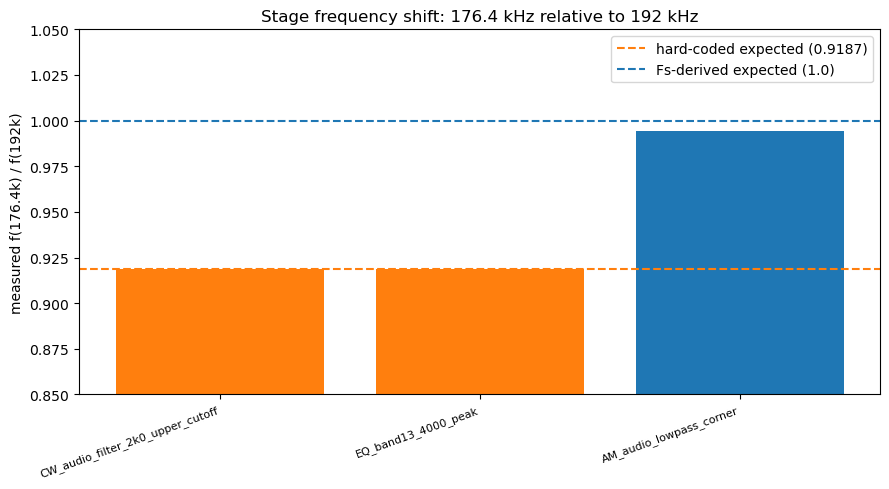

In [6]:
rows = np.genfromtxt('build/176k_stage_shift_summary.txt', delimiter=',',
                     names=True, dtype=None, encoding='utf-8')
print(rows)

labels = [r['stage'] for r in rows]
measured = np.array([r['measured_ratio'] for r in rows])
types = [r['type'] for r in rows]
bar_colors = ['tab:orange' if t == 'hardcoded' else 'tab:blue' for t in types]

plt.figure(figsize=(9, 5))
x = np.arange(len(labels))
plt.bar(x, measured, color=bar_colors)
plt.axhline(RATE_RATIO, color='tab:orange', ls='--', label='hard-coded expected (%.4f)' % RATE_RATIO)
plt.axhline(1.0, color='tab:blue', ls='--', label='Fs-derived expected (1.0)')
plt.xticks(x, labels, rotation=20, ha='right', fontsize=8)
plt.ylim(0.85, 1.05)
plt.ylabel('measured f(176.4k) / f(192k)')
plt.title('Stage frequency shift: 176.4 kHz relative to 192 kHz')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

* **CW audio filters** and **EQ bands** track the `0.91875` ratio — their corner
  and center frequencies drop ~8% because their coefficient tables are frozen at
  the 24 kHz design rate.
* The **AM audio lowpass** (and, by the same mechanism, the decimation /
  interpolation / convolution filters) stays put in Hz.

Running the radio at 176.4 kHz with the DSP unchanged therefore works, with the
only penalty being the ~8% mislabeling/narrowing of the hard-coded CW and EQ
filters. See `docs/RX_DSP_Chain_Parameters.md` for the full stage inventory.
